In [23]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error


In [24]:
# a-) Make a time series plot of the data and verify that it is seasonal. Why do you think
#seasonality is present in these data?
data = [143,191,195,225,175,389,454,618,770,564,327,235, #year1
189,326,289,293,279,552,674,827,1000,502,512,300, #year2
359,264,315,362,414,647,836,901,1104,874,683,352, #year3
332,244,320,437,544,830,1011,1081,1400,1123,713,487 #year4
]
df = pd.DataFrame(data , columns=['Demand'])
df.index = df.index + 1
df

,Demand
1,143
2,191
3,195
4,225
5,175
6,389
7,454
8,618
9,770
10,564


<function matplotlib.pyplot.show(close=None, block=None)>

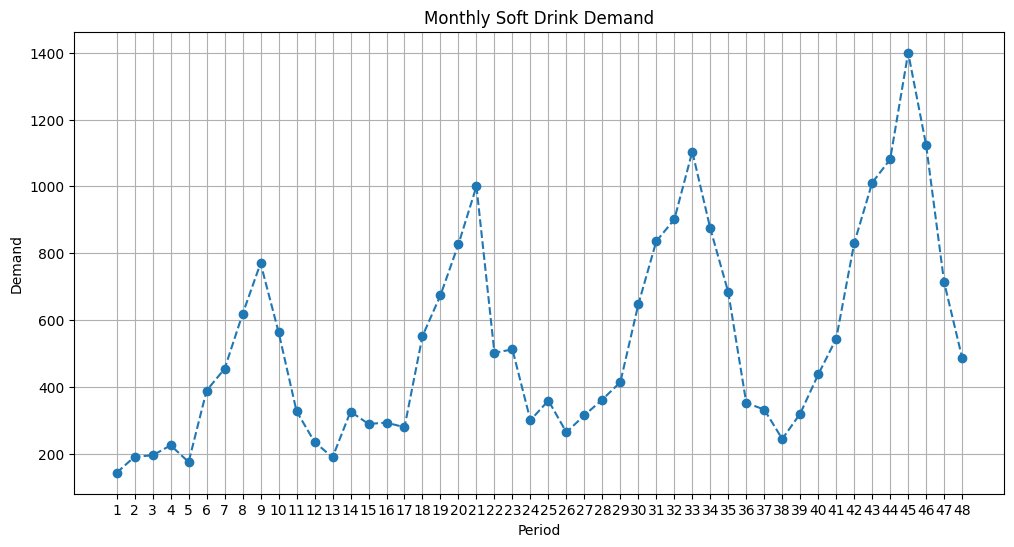

In [25]:
plt.figure(figsize = (12,6))
plt.plot(df.index , df['Demand'], marker = 'o',linestyle = '--')
plt.title('Monthly Soft Drink Demand')
plt.xlabel('Period')
plt.ylabel('Demand')
plt.grid(True)
plt.xticks(np.arange(1,49,1))
plt.show

In [26]:
#b) Use Winters’ multiplicative method for the first 3 years to develop a forecasting method
#for this data. How well does this smoothing procedure work?
#let's split the data for train and test
train_df = df.iloc[:36] #first 3 years
test_df = df.iloc[36:] #last year to predict

#creating Winters multiplicative method.
model = ExponentialSmoothing(
    train_df['Demand'],
    trend  = 'add' ,
    seasonal = 'mul' ,  #multiplicative
    seasonal_periods = 12
).fit()

In [27]:
#C-)Make one-step-ahead forecasts for the last 12 months. Determine the forecast errors. How
#well did your procedure work in forecasting the new data?
predictions = model.forecast(12)

#comparison table
comparison = pd.DataFrame({
    'Actual': test_df['Demand'],
    'Forecast': predictions,
    'Error': test_df['Demand'] - predictions
})

#Mean Absolute Percentage Error
comparison['Absolute Percentage Error'] = (abs(comparison['Error']) / comparison['Actual']) * 100

In [28]:
#Mean Error Metrics
mae = mean_absolute_error(test_df['Demand'], predictions)
mape = mean_absolute_percentage_error(test_df['Demand'], predictions) * 100 # Yüzdeye çevir

print("\nForecast Performance Metrics")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): %{mape:.2f}")
print("\n Prediction Table")
print(comparison)


Forecast Performance Metrics
Mean Absolute Error (MAE): 66.63
Mean Absolute Percentage Error (MAPE): %13.64

 Prediction Table
    Actual     Forecast       Error  Absolute Percentage Error
37     332   365.971862  -33.971862                  10.232489
38     244   388.791631 -144.791631                  59.340832
39     320   400.976602  -80.976602                  25.305188
40     437   439.497865   -2.497865                   0.571594
41     544   443.128084  100.871916                  18.542632
42     830   784.976781   45.023219                   5.424484
43    1011   972.346041   38.653959                   3.823339
44    1081  1135.943406  -54.943406                   5.082646
45    1400  1382.977458   17.022542                   1.215896
46    1123   937.607977  185.392023                  16.508640
47     713   743.316396  -30.316396                   4.251949
48     487   421.918318   65.081682                  13.363795


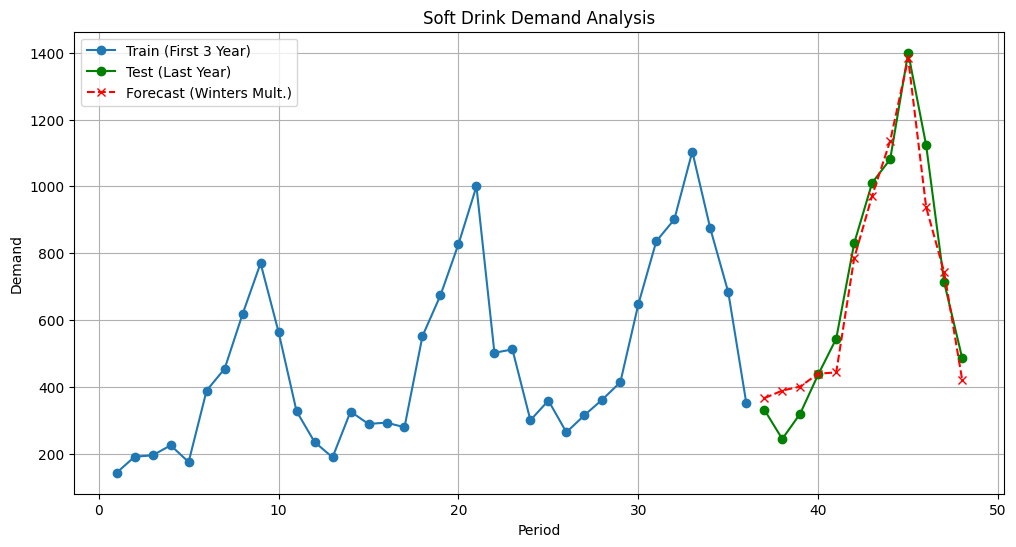

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(train_df.index, train_df['Demand'], label='Train (First 3 Year)', marker='o')
plt.plot(test_df.index, test_df['Demand'], label='Test (Last Year)', color='green', marker='o')
plt.plot(predictions.index, predictions, label='Forecast (Winters Mult.)', color='red', linestyle='--', marker='x')

plt.title("Soft Drink Demand Analysis")
plt.xlabel("Period")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.show()